In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from hea import lm, lme, gam, glm
from hea.data import data
from hea.compare import anova, AIC, BIC
from hea.plot import pairs, interaction_plot

### 1.1.2

In [2]:
hubble = data("hubble", "gamair")
hubble.head()

Galaxy,y,x
enum,i64,f64
"""NGC0300""",133,2.0
"""NGC0925""",664,9.16
"""NGC1326A""",1794,16.14
"""NGC1365""",1594,17.95
"""NGC1425""",1473,21.88


In [3]:
m_hub = lm('y ~ x - 1', data = hubble)
m_hub.summary()

Formula: y ~ x - 1

Residuals:
    Min      1Q Median     3Q    Max
-736.49 -132.52 -19.00 172.18 557.98

Coefficients:
   Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
x    76.581       3.965     68.38      84.78    19.32  1.03e-15  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 24, p = 1, Residual SE = 258.933 on 23 DF
R-Squared = 0.9419, adjusted R-Squared = 0.9394
F-statistics = 373.0807 on 1 and 23 DF, p-value: 1.031907e-15

Log Likelihood = -166.9015, AIC = 337.8030, BIC = 340.1591


In [4]:
m_hub_no_outliers = lm('y ~ x - 1', data = hubble.filter(np.ravel(np.abs(m_hub.residuals)<300)))
m_hub_no_outliers.summary()

Formula: y ~ x - 1

Residuals:
    Min      1Q Median     3Q    Max
-304.25 -141.94 -26.50 138.26 269.78

Coefficients:
   Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
x    77.673       2.970     71.50      83.85    26.15    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 22, p = 1, Residual SE = 180.464 on 21 DF
R-Squared = 0.9702, adjusted R-Squared = 0.9688
F-statistics = 683.8241 on 1 and 21 DF, p-value: 1.659996e-17

Log Likelihood = -145.0066, AIC = 294.0132, BIC = 296.1953


Text(0.5, 0.98, 'm_hub vs. m_hub_no_outliers')

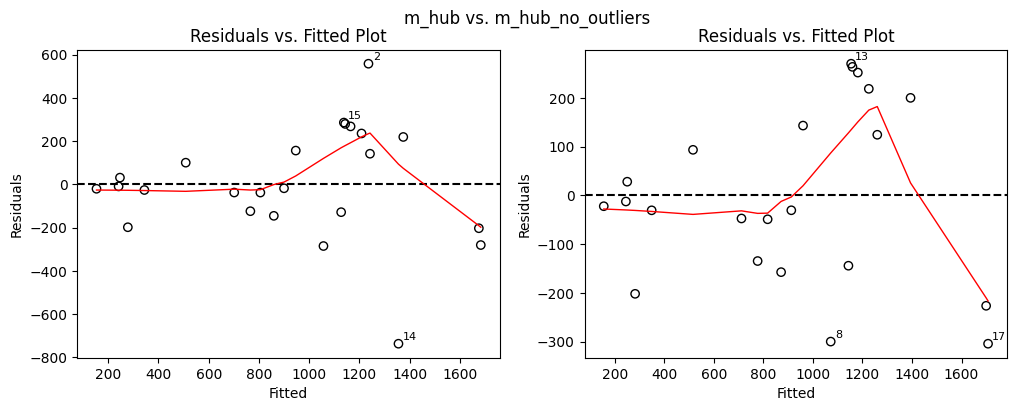

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
m_hub.plot_residuals(ax=ax[0])
m_hub_no_outliers.plot_residuals(ax=ax[1])
fig.suptitle("m_hub vs. m_hub_no_outliers")

### 1.5

In [6]:
sperm = data("sperm.comp1", "gamair")
sperm.head()

subject,time.ipc,prop.partner,count
enum,i64,f64,i64
"""A""",60,0.2,570
"""B""",149,0.98,219
"""D""",70,0.5,485
"""F""",168,0.5,516
"""K""",48,0.2,448


array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

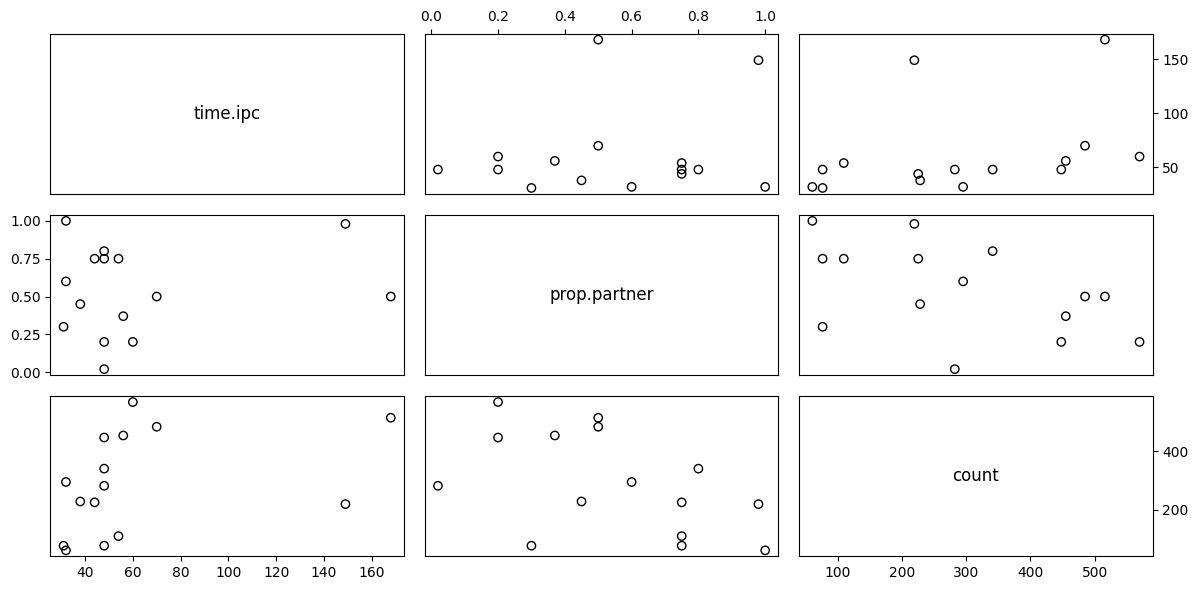

In [7]:
pairs(sperm, figsize=(12,6))

In [8]:
m1_sc = lm("count ~ time.ipc + prop.partner", data=sperm)
m1_sc.summary()

Formula: count ~ time.ipc + prop.partner

Residuals:
     Min      1Q Median     3Q     Max
-239.740 -96.772  2.171 96.837 163.997

Coefficients:
               Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    357.4184     88.0822   165.50390  549.33297    4.058   0.00159  **
time.ipc         1.9416      0.9067    -0.03395    3.91717    2.141   0.05346  .
prop.partner  -339.5602    126.2535  -614.64282  -64.47752   -2.690   0.01969  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 136.609 on 12 DF
R-Squared = 0.4573, adjusted R-Squared = 0.3669
F-statistics = 5.0562 on 2 and 12 DF, p-value: 0.03

Log Likelihood = -93.3673, AIC = 194.7346, BIC = 197.5668


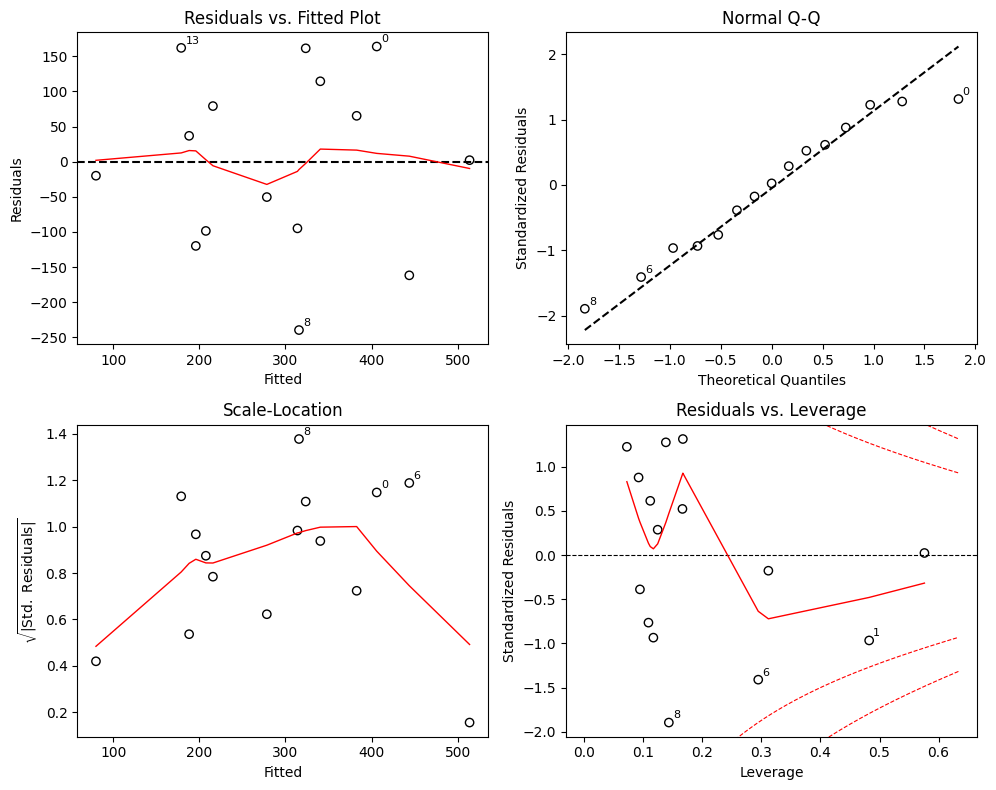

In [9]:
_ = m1_sc.plot()

In [10]:
m1_sc.X

(Intercept),time.ipc,prop.partner
f64,f64,f64
1.0,60.0,0.2
1.0,149.0,0.98
1.0,70.0,0.5
1.0,168.0,0.5
1.0,48.0,0.2
…,…,…
1.0,48.0,0.75
1.0,54.0,0.75
1.0,32.0,0.6


In [11]:
m2_sc = lm('count ~ time.ipc + I(prop.partner * time.ipc)', data=sperm)
m2_sc.summary()

Formula: count ~ time.ipc + I(prop.partner * time.ipc)

Residuals:
    Min      1Q Median     3Q    Max
-187.68 -110.54  18.12 101.95 158.20

Coefficients:
                            Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)                  140.470      64.063    0.8892   280.0506    2.193   0.04877  *
time.ipc                       5.618       1.549    2.2420     8.9936    3.626   0.00348  **
I(prop.partner * time.ipc)    -5.478       1.741   -9.2714    -1.6845   -3.146   0.00843  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 3, Residual SE = 128.023 on 12 DF
R-Squared = 0.5234, adjusted R-Squared = 0.4440
F-statistics = 6.5888 on 2 and 12 DF, p-value: 0.01

Log Likelihood = -92.3937, AIC = 192.7874, BIC = 195.6196


In [12]:
m3_sc = lm('count ~ prop.partner', data=sperm)
m3_sc.summary()

Formula: count ~ prop.partner

Residuals:
    Min      1Q Median     3Q    Max
-287.83 -111.30  18.84 117.45 210.61

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)     451.50       86.23    265.22     637.79    5.236  0.000161  ***
prop.partner   -292.23      140.40   -595.56      11.09   -2.081  0.057727  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 2, Residual SE = 154.301 on 13 DF
R-Squared = 0.2500, adjusted R-Squared = 0.1923
F-statistics = 4.3322 on 1 and 13 DF, p-value: 0.06

Log Likelihood = -95.7944, AIC = 197.5889, BIC = 199.7130


In [13]:
m4_sc = lm('count ~ 1', data=sperm)
AIC(m1_sc, m3_sc, m4_sc)

       df     AIC
m1_sc   4  194.73
m3_sc   3  197.59
m4_sc   2  199.90


In [14]:
sperm2 = data("sperm.comp2", "gamair")
sperm2.head()

pair,n,count,f.age,f.height,f.weight,m.age,m.height,m.weight,m.vol
enum,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""A""",4,514,25,170,64,25,188,95,28
"""B""",27,393,24,175,58,44,180,79,20
"""C""",2,305,22,180,57,20,185,76,null
"""D""",1,485,27,183,66,30,183,67,null
"""E""",1,422,26,163,54,25,183,67,14


Formula: count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol

Residuals:
    Min      1Q Median     3Q    Max
-209.03 -142.71  51.46 118.27 214.47

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -1098.518    1997.984  -5823.00    3625.96  -0.5498     0.600
f.age           10.798      22.755    -43.01      64.60   0.4745     0.650
f.height        -4.639      10.910    -30.44      21.16  -0.4252     0.683
f.weight        19.716      35.709    -64.72     104.16   0.5521     0.598
m.age           -1.722      10.219    -25.89      22.44  -0.1685     0.871
m.height         6.009      10.378    -18.53      30.55   0.5791     0.581
m.weight        -4.619      12.655    -34.54      25.30  -0.3650     0.726
m.vol            5.035      17.652    -36.71      46.78   0.2853     0.784
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 8, Residual SE = 205.146 on 7 DF
R-Squared = 0.2192, adjusted 

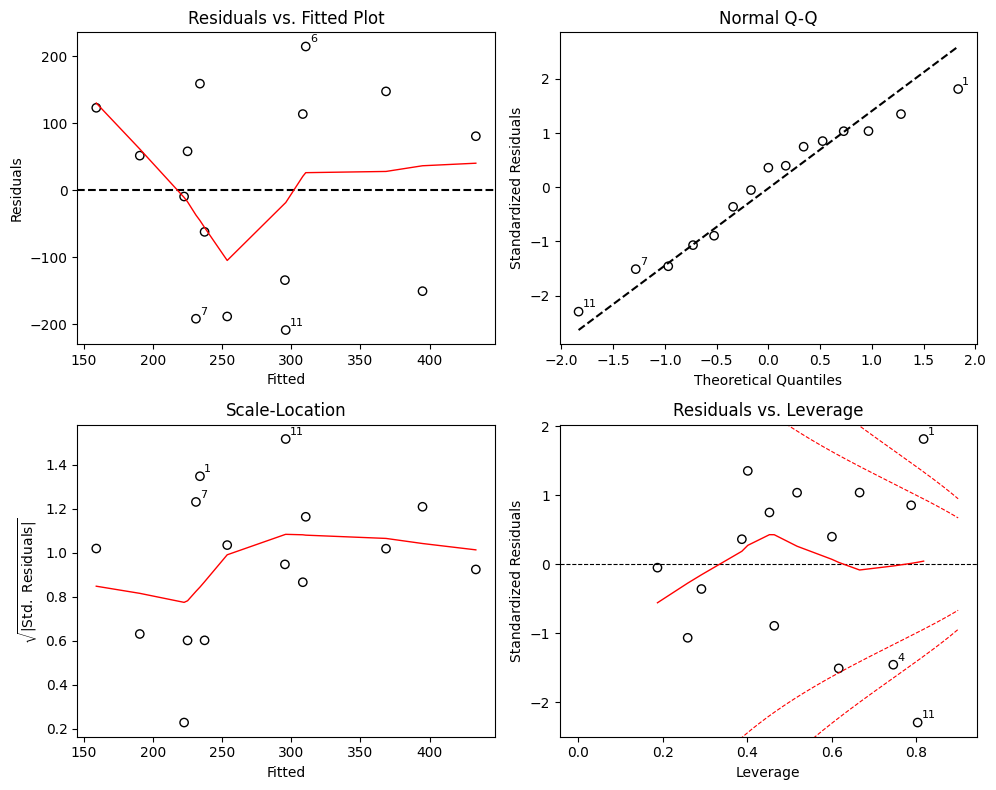

In [15]:
m1_sc2 = lm('count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol', data=sperm2)
m1_sc2.plot()
m1_sc2.summary()

In [16]:
m2_sc2 = lm('count ~ f.age + f.height + f.weight + m.height + m.weight + m.vol', data=sperm2)
m2_sc2.summary()

Formula: count ~ f.age + f.height + f.weight + m.height + m.weight + m.vol

Residuals:
    Min      1Q Median     3Q    Max
-201.98 -144.17  52.52 123.25 219.83

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -1054.770    1856.843  -5336.66    3227.12  -0.5680     0.586
f.age            8.847      18.359    -33.49      51.18   0.4819     0.643
f.height        -5.119       9.871    -27.88      17.64  -0.5186     0.618
f.weight        20.259      33.334    -56.61      97.13   0.6078     0.560
m.height         6.033       9.727    -16.40      28.46   0.6202     0.552
m.weight        -4.473      11.834    -31.76      22.82  -0.3780     0.715
m.vol            4.506      16.281    -33.04      42.05   0.2768     0.789
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 15, p = 7, Residual SE = 192.285 on 8 DF
R-Squared = 0.2160, adjusted R-Squared = -0.3720
F-statistics = 0.3674 on 6 and 8 DF, p-value: 0.88

Log Likelih

In [17]:
m3_sc2 = lm('count ~ f.weight', data=sperm2)
m3_sc2.summary()

Formula: count ~ f.weight

Residuals:
     Min       1Q Median     3Q     Max
-209.741 -119.709  7.465 92.913 273.053

Coefficients:
              Estimate  Std. Error   CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  -1002.281     489.352  -2023.052     18.489   -2.048    0.0539  .
f.weight        22.397       8.629      4.396     40.397    2.595    0.0173  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 22, p = 2, Residual SE = 147.286 on 20 DF
R-Squared = 0.2520, adjusted R-Squared = 0.2146
F-statistics = 6.7363 on 1 and 20 DF, p-value: 0.02

Log Likelihood = -140.0006, AIC = 286.0011, BIC = 289.2743


In [18]:
sperm3 = sperm2.filter(pl.int_range(pl.len()) != 18)
m1_sc3 = lm('count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol', sperm3)
m1_sc3.summary()

Formula: count ~ f.age + f.height + f.weight + m.age + m.height + m.weight + m.vol

Residuals:
     Min      1Q Median     3Q     Max
-104.779 -57.334  2.707 67.302 101.556

Coefficients:
             Estimate  Std. Error    CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  1687.406    1251.338  -1374.5071  4749.3186   1.3485    0.2262
f.age          55.248      15.991     16.1188    94.3764   3.4549    0.0136  *
f.height       21.381       8.419      0.7796    41.9826   2.5395    0.0441  *
f.weight      -88.992      31.737   -166.6485   -11.3348  -2.8041    0.0310  *
m.age         -17.210       6.555    -33.2486    -1.1714  -2.6256    0.0393  *
m.height      -11.321       6.869    -28.1290     5.4873  -1.6481    0.1504
m.weight        6.885       7.287    -10.9450    24.7143   0.9448    0.3812
m.vol          48.996      13.938     14.8916    83.1006   3.5153    0.0126  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 14, p = 8, Residual SE = 109.841 on 6 DF
R

### 1.6.4

In [19]:
PlantGrowth = data("PlantGrowth")
PlantGrowth.head()

weight,group
f64,enum
4.17,"""ctrl"""
5.58,"""ctrl"""
5.18,"""ctrl"""
6.11,"""ctrl"""
4.5,"""ctrl"""


Formula: weight ~ group

Residuals:
      Min        1Q    Median       3Q      Max
-1.071000 -0.418000 -0.006000 0.262750 1.369000

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)    5.0320      0.1971   4.62753    5.43647   25.527    <2e-16  ***
grouptrt1     -0.3710      0.2788  -0.94301    0.20101   -1.331    0.1944
grouptrt2      0.4940      0.2788  -0.07801    1.06601    1.772    0.0877  .
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 30, p = 3, Residual SE = 0.623 on 27 DF
R-Squared = 0.2641, adjusted R-Squared = 0.2096
F-statistics = 4.8461 on 2 and 27 DF, p-value: 0.02

Log Likelihood = -26.8095, AIC = 61.6190, BIC = 67.2238


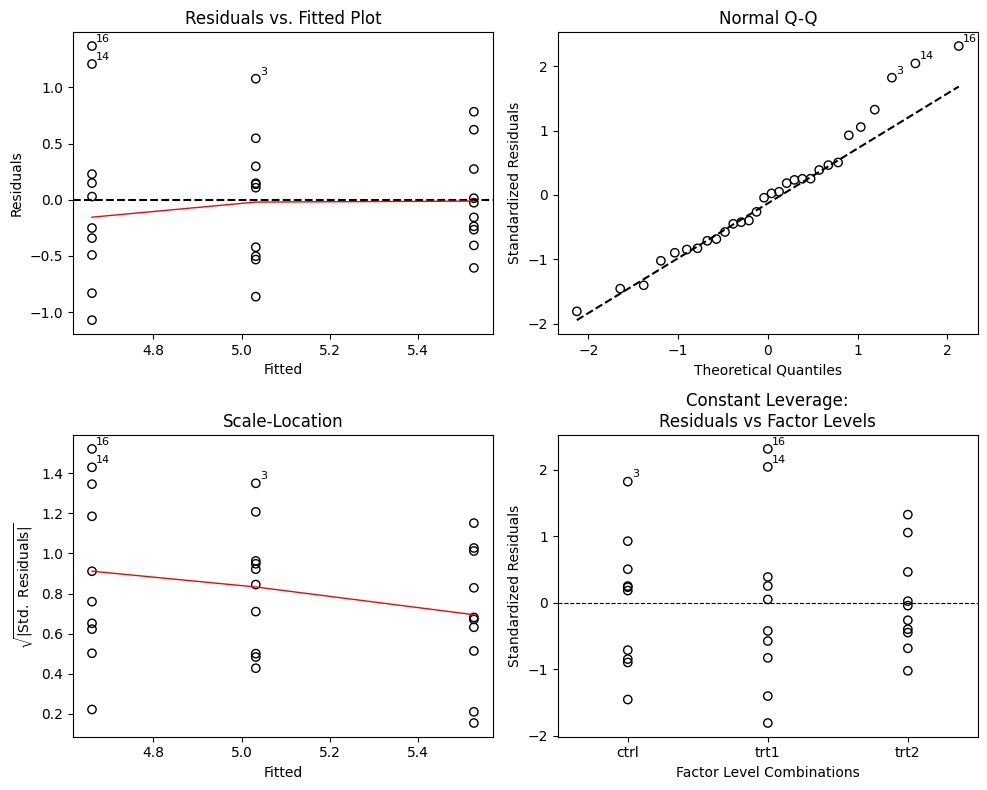

In [20]:
m1_pg = lm('weight ~ group', data=PlantGrowth)
m1_pg.summary()
_ = m1_pg.plot()

In [21]:
m0_pg = lm('weight ~ 1', data=PlantGrowth)
anova(m0_pg, m1_pg)

Analysis of Variance Table

m0_pg: weight ~ 1
m1_pg: weight ~ group

       Res.Df     RSS  Df  Sum of Sq      F   Pr(>F)
m0_pg      29  14.258
m1_pg      27  10.492   2      3.766  4.846  0.01591  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.1.1

In [22]:
stomata = data('stomata', 'gamair')
stomata.head()


area,CO2,tree
f64,enum,enum
1.605574,"""1""","""1"""
1.630071,"""1""","""1"""
1.539119,"""1""","""1"""
1.718732,"""1""","""1"""
1.389616,"""1""","""2"""


In [23]:
m1_st = lm('area ~ CO2 + tree', data=stomata)
m0_st = lm('area ~ CO2', data=stomata)
anova(m0_st, m1_st)

Analysis of Variance Table

m0_st: area ~ CO2
m1_st: area ~ CO2 + tree

       Res.Df    RSS  Df  Sum of Sq      F    Pr(>F)
m0_st      22  2.135
m1_st      18  0.860   4      1.274  6.665  0.001788  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [24]:
m2_st = lm('area ~ tree', data = stomata)
anova(m2_st, m1_st)

Analysis of Variance Table

m2_st: area ~ tree
m1_st: area ~ CO2 + tree

       Res.Df   RSS  Df  Sum of Sq  F  Pr(>F)
m2_st      18  0.86
m1_st      18  0.86   0        0.0
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [25]:
st = (
    stomata
        .group_by("tree", maintain_order=True)
        .summarize(
            pl.col("CO2").first(),
            pl.col("area").mean(),
        )
)
st

tree,CO2,area
enum,enum,f64
"""1""","""1""",1.623374
"""2""","""1""",1.598643
"""3""","""1""",1.162961
"""4""","""2""",2.789238
"""5""","""2""",2.903544
"""6""","""2""",2.329761


In [26]:
m3_st = lm('area ~ CO2', st)
anova(m3_st)

Analysis of Variance Table

Response: area

           Df  Sum Sq  Mean Sq  F value    Pr(>F)
CO2         1  2.2053   2.2053  27.6869  0.006247  **
Residuals   4  0.3186   0.0797
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.1.3

In [27]:
Rail = data("Rail", "nlme")
Rail.head()

Rail,travel
enum,i64
"""1""",55
"""1""",53
"""1""",54
"""2""",26
"""2""",37


In [28]:
m1_rail = lm('travel ~ Rail', data=Rail)
anova(m1_rail)

Analysis of Variance Table

Response: travel

           Df  Sum Sq    Mean Sq   F value     Pr(>F)
Rail        5  9310.5  1862.1000  115.1814  1.033e-09  ***
Residuals  12   194.0    16.1667
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [29]:
rt = (
    Rail
        .group_by("Rail", maintain_order=True)
        .summarize(pl.col("travel").mean())
)
rt

Rail,travel
enum,f64
"""1""",54.0
"""2""",31.666667
"""3""",84.666667
"""4""",96.0
"""5""",50.0
"""6""",82.666667


In [30]:
m0_rail = lm('travel ~ 1', data=rt)
m0_rail.summary()

Formula: travel ~ 1

Residuals:
    Min      1Q Median     3Q    Max
-34.833 -15.500  1.833 17.667 29.500

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)     66.50       10.17     40.35      92.65    6.538   0.00125  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 6, p = 1, Residual SE = 24.914 on 5 DF
R-Squared = 0.0000, adjusted R-Squared = 0.0000
Log Likelihood = -27.2592, AIC = 58.5184, BIC = 58.1019


### 2.1.4

In [31]:
Machines = data("Machines", "nlme")
Machines

Worker,Machine,score
enum,enum,f64
"""1""","""A""",52.0
"""1""","""A""",52.8
"""1""","""A""",53.1
"""2""","""A""",51.8
"""2""","""A""",52.8
…,…,…
"""5""","""C""",72.0
"""5""","""C""",71.1
"""6""","""C""",62.0


<Axes: xlabel='Machine', ylabel='mean of score'>

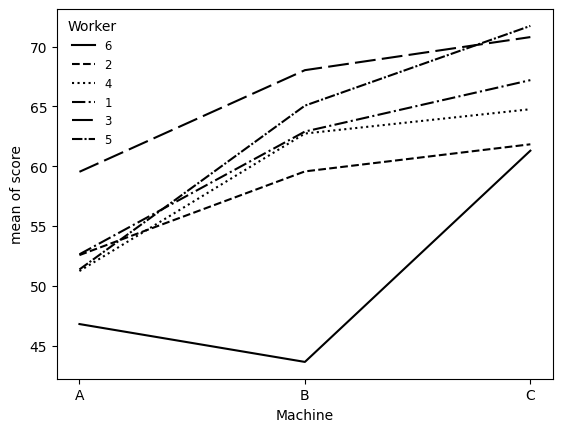

In [32]:
interaction_plot("Machine", "Worker", "score", data=Machines)

In [33]:
m1_mc = lm('score ~ Worker*Machine', data=Machines)
m0_mc = lm('score ~ Worker + Machine', data=Machines)
anova(m0_mc, m1_mc)

Analysis of Variance Table

m0_mc: score ~ Worker + Machine
m1_mc: score ~ Worker*Machine

       Res.Df      RSS  Df  Sum of Sq      F     Pr(>F)
m0_mc      46  459.817
m1_mc      36   33.287  10     426.53  46.13  1.641e-17  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [34]:
mc = (
    Machines
        .group_by("Worker", "Machine")
        .summarize(score=pl.col("score").mean())
        .arrange("Worker", "Machine")
)
mc.head()

Worker,Machine,score
enum,enum,f64
"""6""","""A""",46.8
"""6""","""B""",43.633333
"""6""","""C""",61.3
"""2""","""A""",52.566667
"""2""","""B""",59.566667


In [35]:
m2_mc = lm('score ~ Worker + Machine', mc)
anova(m2_mc)

Analysis of Variance Table

Response: score

           Df    Sum Sq   Mean Sq  F value    Pr(>F)
Worker      5  413.9650   82.7930   5.8232  0.008949  **
Machine     2  585.0878  292.5439  20.5761  0.000286  ***
Residuals  10  142.1767   14.2177
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.5.4

In [36]:

a1 = lme('score ~ Machine + (1|Worker) + (1|Worker:Machine)', data=Machines)
a2 = lme('score ~ Machine + (1|Worker) + (Machine-1|Worker)', data=Machines)
AIC(a1,a2)


    df     AIC
a1   6  227.69
a2  11  230.31


In [37]:
anova(a1, a2)

refitting model(s) with ML (instead of REML)
Analysis of Variance Table (likelihood ratio test)

a1: score ~ Machine + (1|Worker) + (1|Worker:Machine)
a2: score ~ Machine + (1|Worker) + (Machine-1|Worker)

    npar       AIC       BIC     logLik  deviance   Chisq  Df  Pr(>Chisq)
a1     6  237.2695  249.2034  -112.6347  225.2695
a2    11  238.4181  260.2969  -108.2090  216.4181  8.8514   5      0.1151
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 2.5.5

In [38]:
b1 = gam('score ~ Machine + s(Worker, bs="re") + s(Machine, Worker, bs="re")', data=Machines, method='REML')
b1.vcomp


name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",4.781051,2.249858,10.15995
"""s(Machine,Worker)""",3.729538,2.382816,5.837404
"""scale""",0.961577,0.763254,1.211432


In [39]:
b2 = gam('score ~ Machine + s(Worker,bs="re") + s(Worker,bs="re",by=Machine)',data=Machines, method='REML')
b2.vcomp

name,std_dev,lower,upper
str,f64,f64,f64
"""s(Worker)""",3.785947,1.798732,7.968613
"""s(Worker):MachineA""",1.940322,0.253188,14.869794
"""s(Worker):MachineB""",5.874023,2.988334,11.546281
"""s(Worker):MachineC""",2.84547,0.829933,9.75585
"""scale""",0.961577,0.763254,1.211432


In [40]:
AIC(b1, b2)

           df     AIC
b1  18.859954  165.19
b2  18.985573  165.62


### 3.3

In [41]:
heart = pl.DataFrame({
    "ck": [20, 60, 100, 140, 180, 220, 260, 300, 340, 380, 420, 460],
    "ha": [2, 13, 30, 30, 21, 19, 18, 13, 19, 15, 7, 8],
    "ok": [88, 26, 8, 5, 0, 1, 1, 1, 1, 0, 0, 0],
})

heart = heart.with_columns(
    n=pl.col("ha") + pl.col("ok"),
    p=pl.col("ha") / (pl.col("ha") + pl.col("ok")),
)

heart.head()

ck,ha,ok,n,p
i64,i64,i64,i64,f64
20,2,88,90,0.022222
60,13,26,39,0.333333
100,30,8,38,0.789474
140,30,5,35,0.857143
180,21,0,21,1.0


In [42]:
from hea.family import Binomial
m0_heart = glm(
    "p ~ ck",
    data=heart,
    family=Binomial(link="logit"),
    weights=heart["n"].to_numpy(),
)

In [43]:
m0_heart.summary()

Call:
glm(formula = p ~ ck, family = binomial(link=logit))

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  z value  Pr(>|z|)
(Intercept)  -2.758358    0.336696  -3.41827   -2.09845   -8.192  2.56e-16  ***
ck            0.031244    0.003619   0.02415    0.03834    8.633   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1; fixed)

    Null deviance: 271.7124  on 11 degrees of freedom
Residual deviance: 36.9286  on 10 degrees of freedom
AIC: 62.3339    BIC: 63.3037    logLik: -29.1670

Number of Fisher Scoring iterations: 6


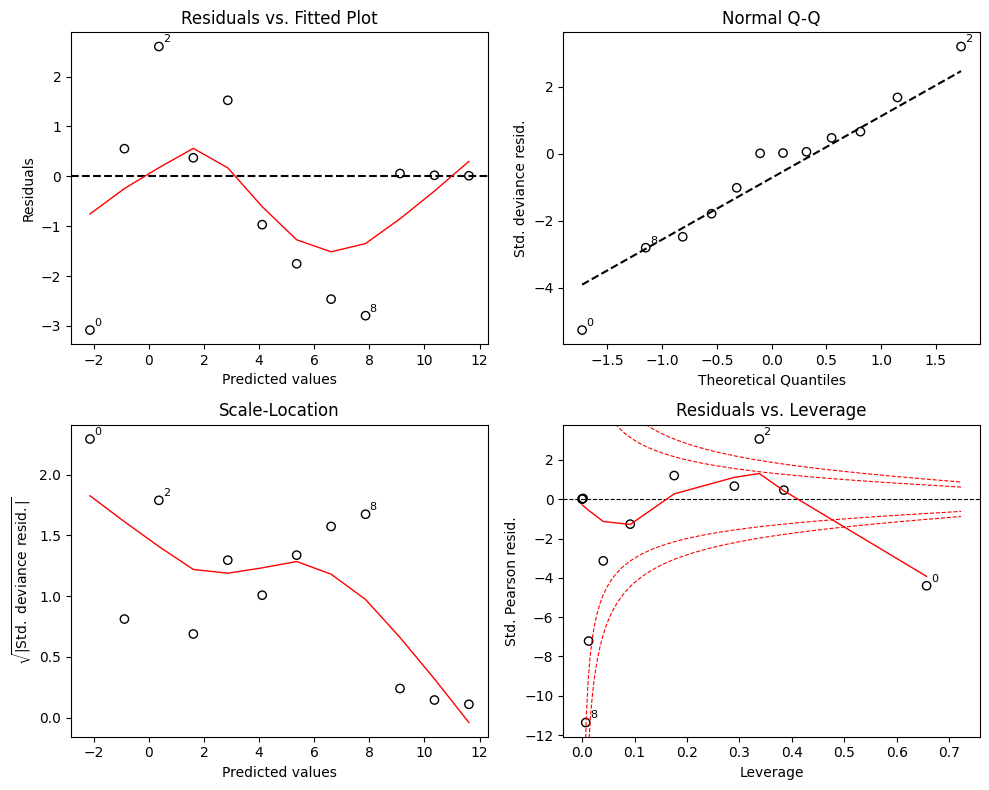

In [44]:
_ = m0_heart.plot()

In [45]:
m1_heart = glm(
    "p ~ ck + I(ck^2) + I(ck^3)",
    data=heart,
    family=Binomial(link="logit"),
    weights=heart["n"].to_numpy(),
)
m1_heart.summary()

Call:
glm(formula = p ~ ck + I(ck^2) + I(ck^3), family = binomial(link=logit))

Coefficients:
               Estimate  Std. Error    CI[2.5%]   CI[97.5]%  z value  Pr(>|z|)
(Intercept)  -5.7858843   0.9268406  -7.6024585  -3.9693100   -6.243  4.30e-10  ***
ck            0.1102205   0.0213900   0.0682968   0.1521441    5.153  2.57e-07  ***
I(ck^2)      -0.0004649   0.0001381  -0.0007355  -0.0001942   -3.367  0.000760  ***
I(ck^3)       6.448e-07   2.544e-07   1.462e-07   1.143e-06    2.535  0.011252  *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1; fixed)

    Null deviance: 271.7124  on 11 degrees of freedom
Residual deviance: 4.2525  on 8 degrees of freedom
AIC: 33.6577    BIC: 35.5974    logLik: -12.8289

Number of Fisher Scoring iterations: 6


In [46]:
anova(m0_heart, m1_heart, test="Chisq")

Analysis of Deviance Table

m0_heart: p ~ ck
m1_heart: p ~ ck + I(ck^2) + I(ck^3)

          Resid. Df  Resid. Dev  Df  Deviance   Pr(>Chi)
m0_heart         10     36.9286
m1_heart          8      4.2525   2   32.6762  8.025e-08  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Text(0, 0.5, 'Proportion Heart Attack')

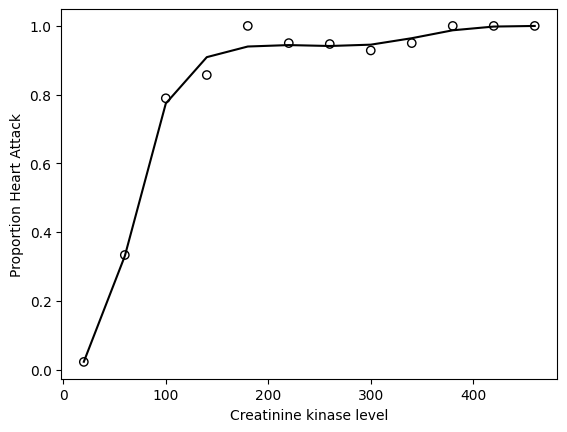

In [47]:
from hea.plot import lines, plot

ax = plot(heart["ck"], heart["p"])
lines(heart["ck"], m1_heart.fitted, ax=ax)
ax.set_xlabel("Creatinine kinase level")
ax.set_ylabel("Proportion Heart Attack")

In [48]:
pois = pl.DataFrame(
    {
        "y": [12,14,33,50,67,74,123,141,165,204,253,246,240],
        "t": np.arange(1, 14),
    }
)
pois

y,t
i64,i64
12,1
14,2
33,3
50,4
67,5
…,…
165,9
204,10
253,11


In [49]:
from hea.family import Poisson
m0_pois = glm("y ~ t", family=Poisson(), data=pois)
m0_pois.summary()


Call:
glm(formula = y ~ t, family = poisson(link=log))

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  z value  Pr(>|z|)
(Intercept)  3.140590    0.078247    2.9872     3.2940    40.14    <2e-16  ***
t            0.202121    0.007771    0.1869     0.2174    26.01    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1; fixed)

    Null deviance: 872.2058  on 12 degrees of freedom
Residual deviance: 80.6865  on 11 degrees of freedom
AIC: 166.3698    BIC: 167.4997    logLik: -81.1849

Number of Fisher Scoring iterations: 4


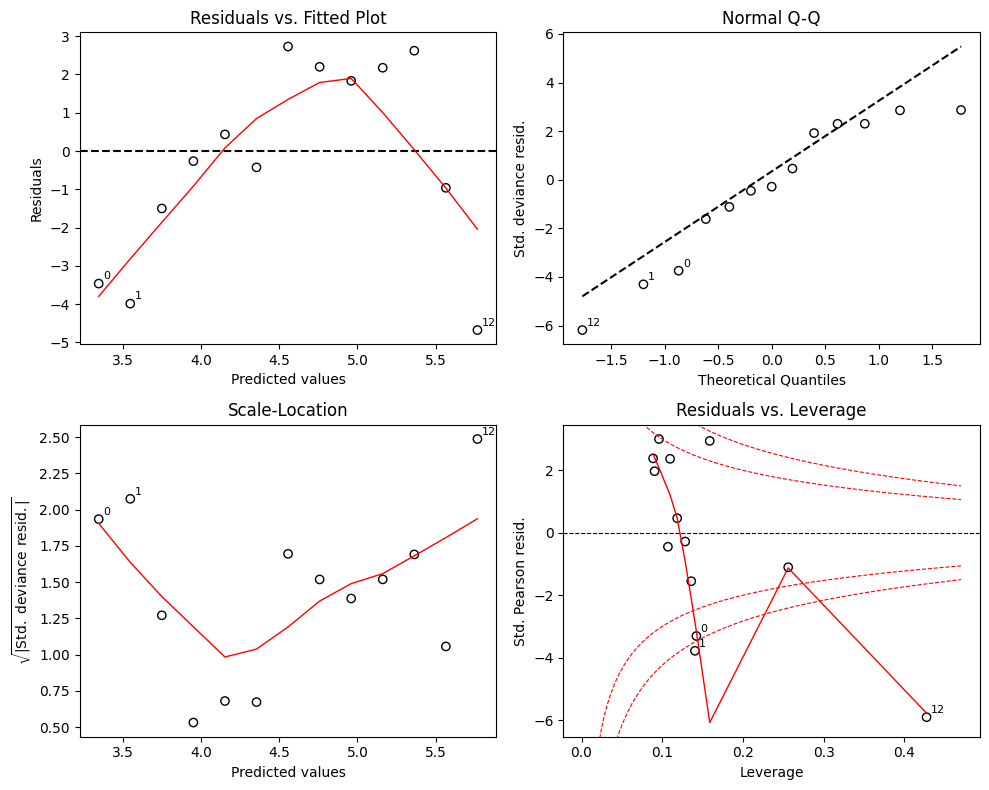

In [50]:
_ = m0_pois.plot()

In [51]:
m1_pois = glm('y ~ t + I(t^2)', family=Poisson(), data=pois)
m1_pois.summary()

Call:
glm(formula = y ~ t + I(t^2), family = poisson(link=log))

Coefficients:
              Estimate  Std. Error  CI[2.5%]  CI[97.5]%  z value  Pr(>|z|)
(Intercept)   1.901459    0.186877   1.53519    2.26773   10.175   < 2e-16  ***
t             0.556003    0.045780   0.46628    0.64573   12.145   < 2e-16  ***
I(t^2)       -0.021346    0.002659  -0.02656   -0.01614   -8.029  9.82e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1; fixed)

    Null deviance: 872.2058  on 12 degrees of freedom
Residual deviance: 9.2402  on 10 degrees of freedom
AIC: 96.9236    BIC: 98.6184    logLik: -45.4618

Number of Fisher Scoring iterations: 4


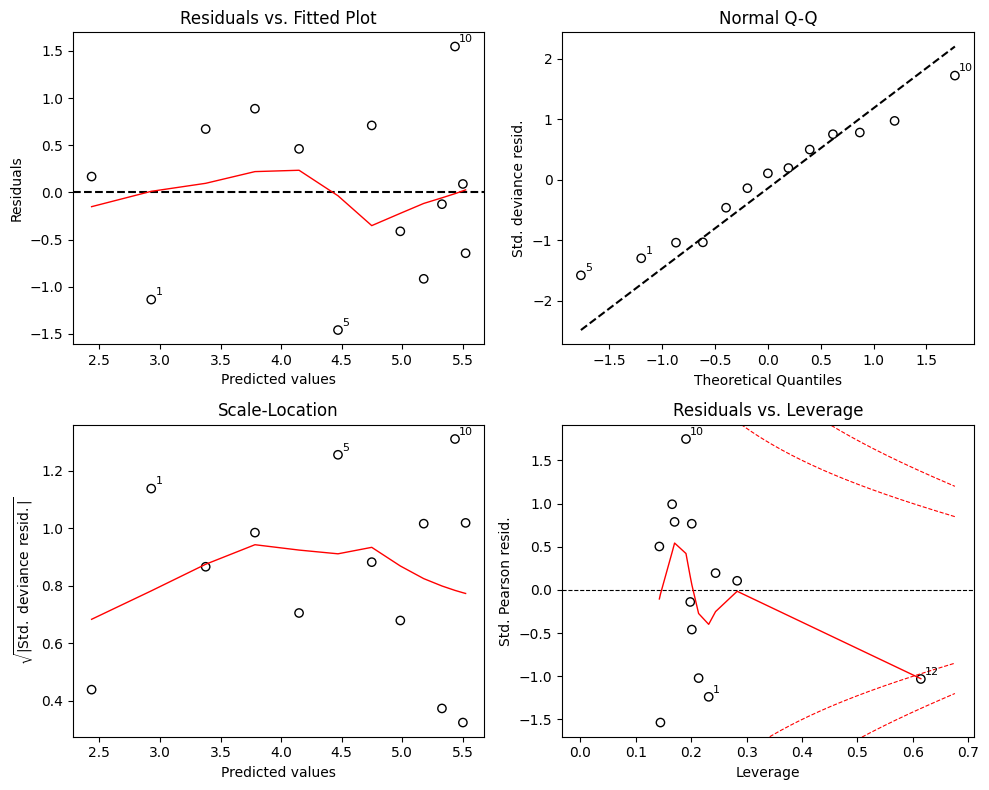

In [52]:
_ = m1_pois.plot()

In [53]:
anova(m0_pois, m1_pois, test="Chisq")

Analysis of Deviance Table

m0_pois: y ~ t
m1_pois: y ~ t + I(t^2)

         Resid. Df  Resid. Dev  Df  Deviance   Pr(>Chi)
m0_pois         11     80.6865
m1_pois         10      9.2402   1   71.4462  2.849e-17  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### 3.5.2

In [54]:
sole = data("sole", "gamair")
sole.head()

rowname,la,lo,t,eggs,stage,a.0,a.1
i64,f64,f64,f64,f64,i64,f64,f64
1,50.055,-5.87,49.5,0.0,1,0.0,2.4
2,50.09,-6.146,49.5,0.0,1,0.0,2.4
3,50.123,-6.39,49.5,0.0,1,0.0,2.4
4,50.178,-6.15,49.5,0.0,1,0.0,2.4
5,50.188,-5.902,49.5,0.0,1,0.0,2.4


In [55]:
sole = sole.mutate(
    off=(pl.col("a.1") - pl.col("a.0")).log(),
    a=(pl.col("a.1") + pl.col("a.0")) / 2
)
solr = sole.mutate(
    t=(pl.col("t") - pl.col("t").mean()) / pl.col("t").std(),
    la=pl.col("la") - pl.col("la").mean(),
    lo=pl.col("lo") - pl.col("lo").mean(),
)

In [56]:
from hea.family import Quasi
formula = """
    eggs ~ offset(off) + lo + la + t
    + I(lo*la) + I(lo^2) + I(la^2) + I(t^2)
    + I(lo*t) + I(la*t) + I(lo^3) + I(la^3) + I(t^3)
    + I(lo*la*t) + I(lo^2*la) + I(lo*la^2)
    + I(lo^2*t) + I(la^2*t) + I(la*t^2) + I(lo*t^2)
    + a + I(a*t) + I(t^2*a)
"""
b0 = glm(formula, family=Quasi(link="log", variance="mu"), data=solr)
b0.summary()


Call:
glm(formula = 
    eggs ~ offset(off) + lo + la + t
    + I(lo*la) + I(lo^2) + I(la^2) + I(t^2)
    + I(lo*t) + I(la*t) + I(lo^3) + I(la^3) + I(t^3)
    + I(lo*la*t) + I(lo^2*la) + I(lo*la^2)
    + I(lo^2*t) + I(la^2*t) + I(la*t^2) + I(lo*t^2)
    + a + I(a*t) + I(t^2*a)
, family = quasi(link=log, variance='mu'))

Coefficients:
                 Estimate  Std. Error    CI[2.5%]   CI[97.5]%   t value  Pr(>|t|)
(Intercept)      -0.03836     0.14561   -0.323749    0.247020   -0.2635  0.792215
lo                5.22548     0.39438    4.452505    5.998460   13.2498   < 2e-16  ***
la               -5.94345     0.50139   -6.926148   -4.960743  -11.8540   < 2e-16  ***
t                -2.43222     0.25762   -2.937148   -1.927284   -9.4410   < 2e-16  ***
I(lo * la)        3.38576     0.61801    2.174484    4.597046    5.4785  5.00e-08  ***
I(lo^2)          -3.98406     0.36747   -4.704288   -3.263828  -10.8418   < 2e-16  ***
I(la^2)          -4.21517     0.56232   -5.317294   -3.113051   -

In [57]:
b1 = gam(formula, family=Quasi(link="log", variance="mu"), data=solr, method="REML")
b1.summary()


Family: quasi
Link function: log

Formula: 
    eggs ~ offset(off) + lo + la + t
    + I(lo*la) + I(lo^2) + I(la^2) + I(t^2)
    + I(lo*t) + I(la*t) + I(lo^3) + I(la^3) + I(t^3)
    + I(lo*la*t) + I(lo^2*la) + I(lo*la^2)
    + I(lo^2*t) + I(la^2*t) + I(la*t^2) + I(lo*t^2)
    + a + I(a*t) + I(t^2*a)


Parametric coefficients:
                 Estimate  Std. Error   t value  Pr(>|t|)
(Intercept)      -0.03836     0.14561   -0.2635  0.792220
lo                5.22548     0.39439   13.2495   < 2e-16  ***
la               -5.94345     0.50140  -11.8538   < 2e-16  ***
t                -2.43222     0.25764   -9.4405   < 2e-16  ***
I(lo * la)        3.38576     0.61804    5.4782  5.01e-08  ***
I(lo^2)          -3.98406     0.36751  -10.8406   < 2e-16  ***
I(la^2)          -4.21517     0.56234   -7.4957  1.10e-13  ***
I(t^2)           -1.77607     0.26286   -6.7567  1.99e-11  ***
I(lo * t)         0.20029     0.35128    0.5702  0.568634
I(la * t)         1.82637     0.47342    3.8578  0.00011

### 4.6

In [58]:
trees = data("trees", "mgcv")

In [59]:
from hea.family import Gamma
ct1 = gam('Volume ~ s(Height) + s(Girth)', family=Gamma(link="log"), data=trees)
ct1.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.32  6.51e-06  ***
s(Girth)   2.422   3.044  219.28   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.0080824  Scale est. = 0.006899  n = 31


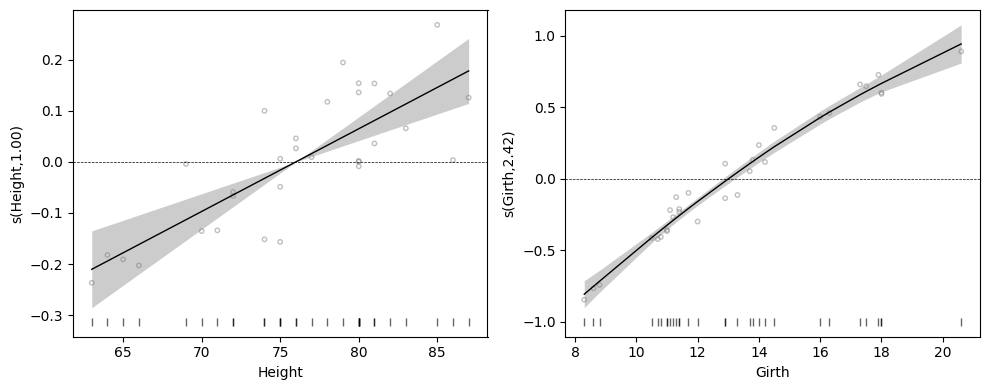

In [60]:
ax = ct1.plot_smooth(partial_residuals=True)

In [61]:
ct2 = gam(
    'Volume ~ s(Height, bs="cr") + s(Girth, bs="cr")', 
    family=Gamma(link="log"), 
    data=trees
)
ct2.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height, bs="cr") + s(Girth, bs="cr")

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.32  6.50e-06  ***
s(Girth)   2.419   3.035  219.51   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.0080805  Scale est. = 0.006898  n = 31


In [62]:
ct3 = gam(
    'Volume ~ s(Height) + s(Girth, bs="cr", k=20)', 
    family=Gamma(link="log"), 
    data=trees
)
ct3.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth, bs="cr", k=20)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27570     0.01492    219.6    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.31  6.52e-06  ***
s(Girth)   2.424   3.049  218.92   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.8%
GCV = 0.008083  Scale est. = 0.006899  n = 31


In [63]:
ct4 = gam(
    'Volume ~ s(Height) + s(Girth)', 
    family=Gamma(link="log"), gamma=1.4,
    data=trees,
)
ct4.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height) + s(Girth)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27577     0.01504    217.8    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
             edf  Ref.df       F   p-value
s(Height)  1.000   1.000   31.51  6.02e-06  ***
s(Girth)   2.170   2.735  237.10   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.972  Deviance explained = 97.7%
GCV = 0.009228  Scale est. = 0.0070127  n = 31


In [64]:
ct5 = gam("Volume ~ s(Height, Girth, k=25)", family=Gamma(link="log"), data=trees)
ct5.summary()


Family: Gamma
Link function: log

Formula: Volume ~ s(Height, Girth, k=25)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27583     0.01579    207.4    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                   edf  Ref.df      F  p-value
s(Height,Girth)  4.791   6.487  161.5   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.966  Deviance explained = 97.7%
GCV = 0.0093576  Scale est. = 0.0077321  n = 31


In [65]:
ct5.plot_smooth()

ValueError: no plottable 1D smooths in this model; multivariate / fs / re smooths aren't supported here

In [ ]:
ct6 = gam("Volume ~ te(Height, Girth, k=5)", family=Gamma(link="log"), data=trees)
ct6.summary()


Family: Gamma
Link function: log

Formula: Volume ~ te(Height, Girth, k=5)

Parametric coefficients:
             Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)   3.27584     0.01522    215.2    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                    edf  Ref.df      F  p-value
te(Height,Girth)  3.000   3.000  377.2   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.973  Deviance explained = 97.7%
GCV = 0.0081971  Scale est. = 0.0071821  n = 31


In [ ]:
_ = ct6.plot_smooth()

ValueError: no plottable 1D smooths in this model; multivariate / fs / re smooths aren't supported here

In [ ]:
from hea import factor
trees.mutate(
    factor((pl.col("Height") / 10).floor() - 5, levels=["small", "medium", "large"])
)

InvalidOperationError: conversion from `str` to `enum` failed in column 'Height' for 31 out of 31 values: ["2.0", "1.0", … "2.0"]

Ensure that all values in the input column are present in the categories of the enum datatype.

This error occurred in the following expression:
	[([(col("Height")) / (10)].floor()) - (5.0)].strict_cast(String).strict_cast(Enum([...]))


### 7.2

In [ ]:
brain = data("brain", "gamair")
brain = brain.filter(pl.col("medFPQ") > 5e-3)

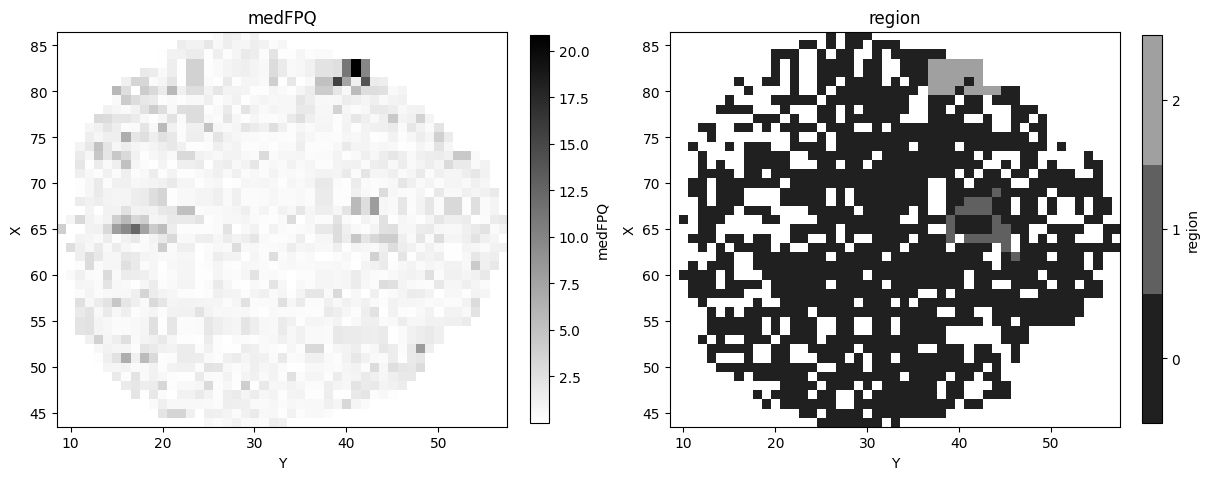

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_min, X_max = brain["X"].min(), brain["X"].max()
Y_min, Y_max = brain["Y"].min(), brain["Y"].max()
nx = X_max - X_min + 1
ny = Y_max - Y_min + 1

medFPQ = np.full((nx, ny), np.nan)   # rows=X, cols=Y
region = np.full((nx, ny), np.nan)
for row in brain.iter_rows(named=True):
    i = row["X"] - X_min   # row index = X
    j = row["Y"] - Y_min   # col index = Y
    medFPQ[i, j] = row["medFPQ"]
    if row["region"] is not None:
        region[i, j] = row["region"]

extent = (Y_min - 0.5, Y_max + 0.5, X_min - 0.5, X_max + 0.5)  # (left, right, bottom, top)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

im0 = axes[0].imshow(medFPQ, origin="lower", cmap="gray_r",
                     aspect="equal", extent=extent)
fig.colorbar(im0, ax=axes[0], label="medFPQ", shrink=0.8)
axes[0].set(xlabel="Y", ylabel="X", title="medFPQ")

cmap_reg = ListedColormap(["#202020", "#606060", "#A0A0A0"])
im1 = axes[1].imshow(region, origin="lower", cmap=cmap_reg,
                     aspect="equal", vmin=-0.5, vmax=2.5, extent=extent)
fig.colorbar(im1, ax=axes[1], ticks=[0, 1, 2],
             label="region", shrink=0.8)
axes[1].set(xlabel="Y", ylabel="X", title="region")
plt.show()

In [ ]:
m0 = gam('medFPQ ~ s(Y, X, k=100)', data=brain)
m1 = gam('medFPQ^.25 ~ s(Y, X, k=100)', data=brain)
m2 = gam('medFPQ ~ s(Y, X, k=100)', data=brain, family=Gamma(link="log"))
m3 = gam('medFPQ ~ s(Y,k=30) + s(X,k=30)', data=brain, family=Gamma(link="log"))

tm = gam('medFPQ ~ te(Y, X, k=10)', data=brain, family=Gamma(link="log"))

# (d) main effects + interaction, estimated separately
tm1 = gam('medFPQ ~ s(Y, k=10, bs="cr") + s(X, k=10, bs="cr") + ti(Y, X, k=10)',
          data=brain, family=Gamma(link="log"))

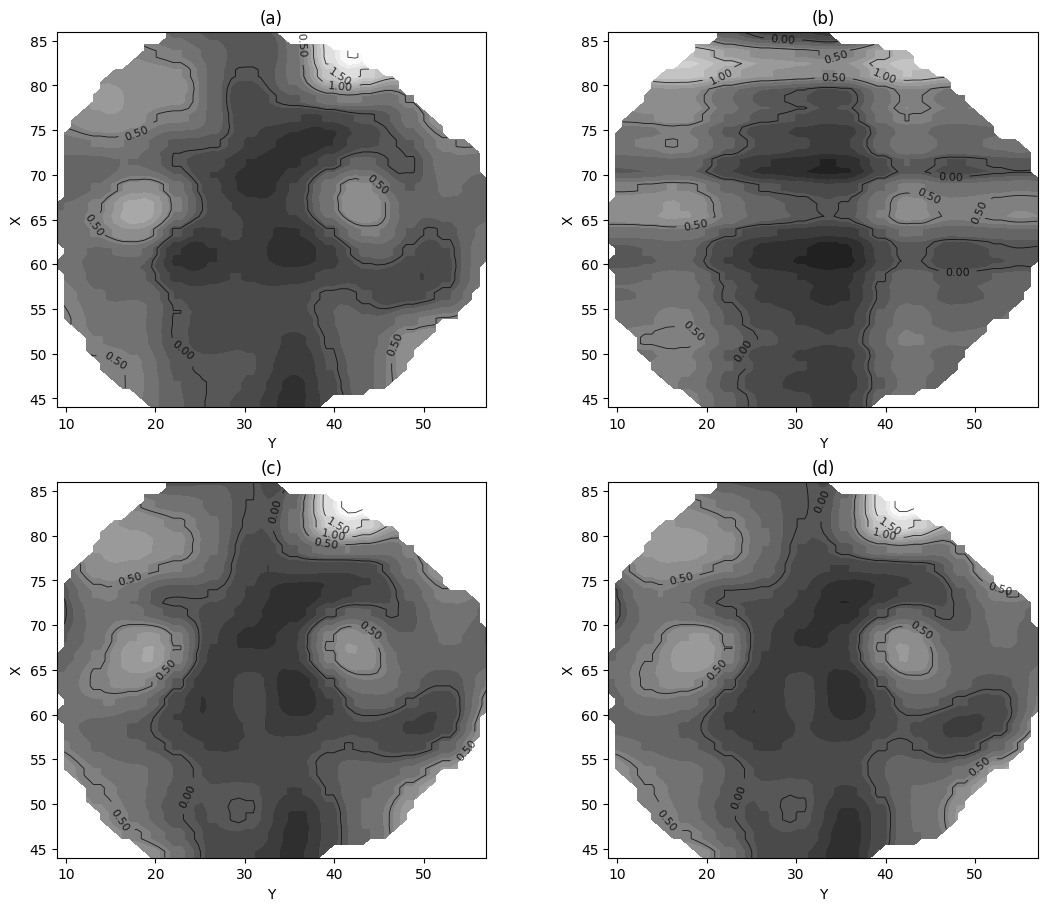

In [ ]:
fig, axes = plt.subplot_mosaic(
    [["a", "b"],
     ["c", "d"]],
    figsize=(11, 9),
    constrained_layout=True,
)
for label, m in zip("abcd", [m2, m3, tm, tm1]):
    m.vis(view=("Y", "X"), too_far=0.03, n_grid=60).plot(
        kind="contour",
        ax=axes[label],
        cmap="gray",
        levels=np.linspace(-1, 2, 20),
        contour_levels=np.linspace(0, 2, 5),
        colorbar=False,
        clabel=True,
    )
    axes[label].set_title(f"({label})")
plt.show()